In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,f1_score
import pickle as pickle

In [3]:
data=pd.read_csv('placementdata.csv')
df_data=pd.DataFrame(data)
df_data.head()
df_data.columns

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='object')

In [6]:
df_data['SoftSkillsRating'].min()

np.float64(3.0)

In [3]:
df_data=df_data.drop('StudentID',axis=1)

In [4]:
cols_to_change=['ExtracurricularActivities','PlacementTraining']
for i in cols_to_change:
    df_data[i]=df_data[i].map({'Yes':1,'No':0})


In [5]:
df_data['PlacementStatus']=df_data['PlacementStatus'].map({'Placed':1,'NotPlaced':0})

In [127]:
df_data['f3']=df_data['AptitudeTestScore']*df_data['HSC_Marks']*df_data['SSC_Marks']*df_data['SoftSkillsRating']*df_data['CGPA']
df_data['f4']=(df_data['PlacementTraining']+df_data['ExtracurricularActivities'])/2



In [141]:
df_data=df_data.drop('f4',axis=1)

KeyError: "['f4'] not found in axis"

In [142]:
df_data.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus,f3
0,7.5,1,1,1,65,4.4,0,0,61,79,0,10336755.0
1,8.9,0,3,2,90,4.0,1,1,78,82,1,20492784.0
2,7.3,1,2,2,82,4.8,1,0,79,80,0,18159129.6
3,7.5,1,1,2,85,4.4,1,1,81,80,1,18176400.0
4,8.3,1,2,2,86,4.5,1,1,74,88,1,20917195.2


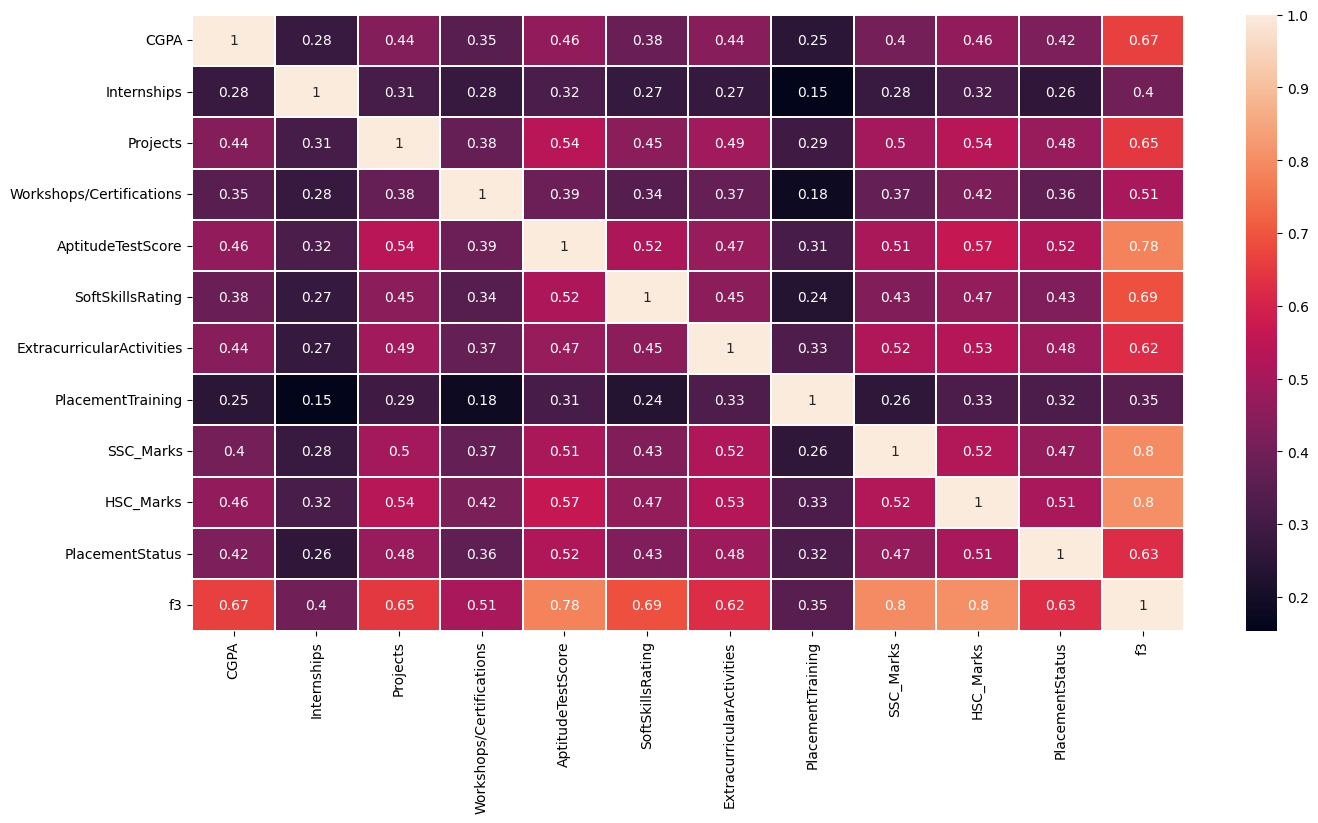

In [133]:
plt.figure(figsize=(16,8))
sns.heatmap(df_data.corr(),annot=True,linewidths=0.25)
plt.show()

In [152]:
cols_to_train=['f3','f4']
x=df_data.drop('PlacementStatus',axis=1)
y=df_data['PlacementStatus']
x


,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,f3
0,7.5,1,1,1,65,4.4,0,0,61,79,10336755.00
1,8.9,0,3,2,90,4.0,1,1,78,82,20492784.00
2,7.3,1,2,2,82,4.8,1,0,79,80,18159129.60
3,7.5,1,1,2,85,4.4,1,1,81,80,18176400.00
4,8.3,1,2,2,86,4.5,1,1,74,88,20917195.20
...,...,...,...,...,...,...,...,...,...,...,...
9995,7.5,1,1,2,72,3.9,1,0,85,66,11814660.00
9996,7.4,0,1,0,90,4.8,0,0,84,67,17991590.40
9997,8.4,1,3,0,70,4.8,1,1,79,81,18060537.60
9998,8.9,0,3,2,87,4.8,1,1,71,85,22429922.40


In [143]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=25)


In [25]:
rand=RandomForestClassifier()
param_grid={'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]}
model=RandomizedSearchCV(rand,param_distributions=param_grid,n_iter=10,cv=5,scoring="accuracy")
model.fit(x_train,y_train)



,estimator,RandomForestClassifier()
,param_distributions,"{'bootstrap': [True, False], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


0.916

In [61]:
models=[]
models.append(("Naive Bayes",GaussianNB()))
models.append(("RandomForestClassifier",RandomForestClassifier()))
models.append(('KNeighborsClassifier',KNeighborsClassifier(n_neighbors=5)))
models.append(('Decision tree',DecisionTreeClassifier()))



In [144]:
for name , model in models:
    print(name,model)
    model.fit(x_train,y_train)
    y_predict=model.predict(x_test)
    print(confusion_matrix(y_test,y_predict))
    print('accuracy_score',accuracy_score(y_test,y_predict))
    print('precision_score',precision_score(y_test,y_predict))
    print('recall score',recall_score(y_test,y_predict))
    print('f1_score',f1_score(y_test,y_predict))
    print()
    

Naive Bayes GaussianNB()
[[1219  222]
 [ 315  744]]
accuracy_score 0.7852
precision_score 0.7701863354037267
recall score 0.7025495750708215
f1_score 0.7348148148148148

RandomForestClassifier RandomForestClassifier()
[[1200  241]
 [ 292  767]]
accuracy_score 0.7868
precision_score 0.7609126984126984
recall score 0.724268177525968
f1_score 0.7421383647798742

KNeighborsClassifier KNeighborsClassifier()
[[1163  278]
 [ 332  727]]
accuracy_score 0.756
precision_score 0.7233830845771144
recall score 0.6864966949952785
f1_score 0.7044573643410853

Decision tree DecisionTreeClassifier()
[[1097  344]
 [ 363  696]]
accuracy_score 0.7172
precision_score 0.6692307692307692
recall score 0.6572237960339944
f1_score 0.6631729394949977



In [151]:
best_model=RandomForestClassifier()

best_model.fit(x_train,y_train)
best_model.predict(x_test)



array([0, 0, 1, ..., 0, 0, 0], shape=(2500,))

In [146]:
with open('place.pkl','wb') as file:
    pickle.dump(best_model,file)